<a href="https://colab.research.google.com/github/samiahmed99/mitcourse/blob/main/Real_Time_Retail_Feedback_Intelligence_Low_code_sami_ahmed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
Why is this problem important to solve?

ChicStyle is a fashion retail platform that gets flooded with customer reviews during festive seasons and holiday sales. The problem is speed and nuance. When thousands of reviews land every hour, the team can't manually sift through them fast enough to catch urgent complaints about fit, defects, or delivery before customers feel ignored. Traditional sentiment tools make it worse by oversimplifying: they slap a single positive/negative label on a review like "The fit is great but the colour was nothing like the image," missing that the customer is happy about one thing and unhappy about another. Delayed or tone-deaf responses during emotionally charged shopping periods (gifts, celebrations) erode trust, kill repeat purchases, and damage the brand. The business needs a system that reads reviews with the same contextual understanding a human would, just at scale and in real time.

### **Objective**

What is the intended goal?

Build a Gen AI feedback analysis system using prompt engineering (Zero-Shot, Few-Shot, Chain-of-Thought) that can take raw customer reviews and produce structured, actionable output: sentiment classification (positive/negative/neutral), feedback category (fit, quality, delivery, price, etc.), urgency level (high/medium/low inferred from the language), a personalised customer response message, and a concise retail team report. All of this grouped by product category and urgency so the right teams can act on the right issues immediately.

### **Dataset Used for the Notebook**
Describe dataset used for this project.

The project uses the Women's E-Commerce Clothing Reviews dataset, containing 23,486 reviews across 10 columns. The core input is Review.Text, the free-text review body. Supporting fields include Rating (1 to 5), Recommended.IND (binary), Title, Age, and Positive.Feedback.Count. Products are organised into three hierarchical categoricals: Division.Name (General, General Petite, Intimates), Department.Name (six categories led by Tops and Dresses), and Class.Name (20 sub-categories). The data skews heavily positive, with 56% being 5-star ratings and 82% recommended, which means the system needs to be particularly sharp at surfacing the minority negative and urgent reviews. There are 845 missing review texts (dropped, since text is the entire input to the AI pipeline) and 3,810 missing titles.

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [1]:
# Install the required libraries for the project
# --- Installation of Required Libraries ---
!pip install pandas matplotlib seaborn
!pip install -q -U google-genai
!pip install openai
!pip install wordcloud
!pip install plotly


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 21.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.


In [2]:
# Import the required libraries for the project
# --- Core Utilities ---
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

# --- Data Handling ---
import pandas as pd
from google.colab import userdata

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- Progress Bar ---
from tqdm import tqdm

# --- OpenAI Client ---
import openai

# Set global plot style
sns.set_style("whitegrid")

### **Data Loading**
### Loading and Understanding the Data


In [5]:
### Loading and Understanding the Data
# Load the dataset from 'data.csv'. Remember that the separator is a semicolon (';')
# and the first column should be used as the index.

!git clone https://github.com/samiahmed99/mitcourse.git
df = pd.read_csv('/content/mitcourse/data.csv', sep=';', index_col=0)
display(df)

### Sami's version of loading the data from git:
##df = pd.read_csv("Boston.csv") ## Complete the code
#!git clone https://github.com/samiahmed99/mitcourse.git
#df = pd.read_csv('/content/mitcourse/data.csv')
#df.head()
#display(df)

fatal: destination path 'mitcourse' already exists and is not an empty directory.


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


### **Data Overview**

In [6]:
# Get a summary of the dataset to check data types and non-null counts
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review.Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended.IND          23486 non-null  int64 
 6   Positive.Feedback.Count  23486 non-null  int64 
 7   Division.Name            23472 non-null  object
 8   Department.Name          23472 non-null  object
 9   Class.Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


### **Sanity checks**

In [7]:
# Check for the total number of missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

In [8]:
df = df.dropna(subset=['Review.Text'])  #Sami - avoid analyzing garbage where there is null, so delete the null review text rows

print("\nMissing Values after cleaning:")
print(df.isnull().sum())


Missing Values after cleaning:
Clothing.ID                   0
Age                           0
Title                      2966
Review.Text                   0
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                13
Department.Name              13
Class.Name                   13
dtype: int64


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.


In [9]:
## 4.1 Overall Sentiment: Distribution of Product Ratings
# Create a histogram using Plotly Express to visualize the distribution of the 'Rating' column.
# This will help you understand the overall customer sentiment.

fig = px.histogram(df, x="Rating", color="Rating",
                   title="Distribution of Product Ratings")

fig.update_layout(
    xaxis_title="Rating (1-5)",
    yaxis_title="Number of Reviews"
)
fig.show()

In [10]:
## 4.2 Performance by Category: Average Rating by Department
# Calculate the average rating for each department.
# Group the DataFrame by 'Department.Name' and calculate the mean of the 'Rating'.

avg_rating_by_dept = df.groupby('Department.Name')['Rating'].mean().sort_values(ascending=False).reset_index()

# Create a horizontal bar chart to show the average rating for each department.
fig = px.bar(avg_rating_by_dept,
             x='Rating',
             y='Department.Name',
             orientation='h',
             title="Average Customer Rating by Department",
             color='Rating')
fig.show()

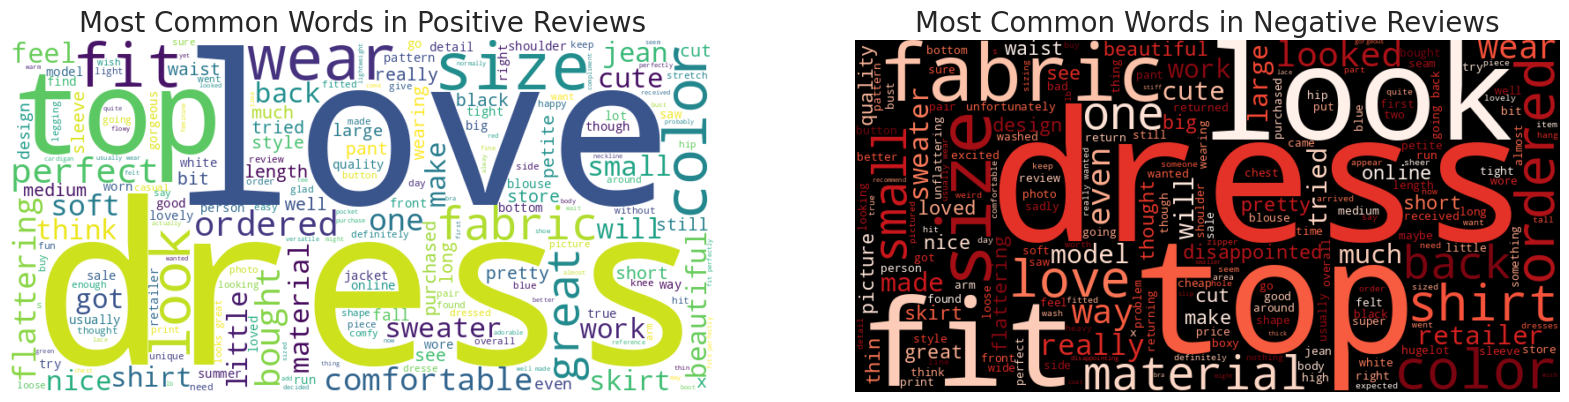

In [13]:
## 4.3 Qualitative Insights: Word Clouds for Positive vs. Negative Reviews
# Separate the reviews into two strings: one for positive (Rating >= 4) and one for negative (Rating <= 2).
positive_reviews = " ".join(df[df['Rating'] >= 4]['Review.Text'])
negative_reviews = " ".join(df[df['Rating'] <=2]['Review.Text'])

# Generate a WordCloud for positive reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

# Generate a WordCloud for negative reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

# Plot the word clouds side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(wordcloud_positive, interpolation='bilinear')
ax1.set_title('Most Common Words in Positive Reviews', fontsize=20)
ax1.axis('off')
ax2.imshow(wordcloud_negative, interpolation='bilinear')
ax2.set_title('Most Common Words in Negative Reviews', fontsize=20)
ax2.axis('off')
plt.show()

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results. Use gpt-4o-mini model

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

In [14]:
# --- OpenAI API Setup ---
# Fetch your stored API key.
api_key = userdata.get('OPENAI_API_KEY')

# Initialize the OpenAI client. Provide your API key and the custom base URL.
client = openai.OpenAI(
    api_key="gl-U2FsdGVkX194sgBsPjh5Tb9KZkRWCjoEsaNbrOvDjNMAEYWLUwavkn4uGwindcSg",
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

model_name = "gpt-4o-mini"



#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another Free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [15]:
# Create a sample of 50 reviews to work with.
df_sample_copy = df.sample(n=50, random_state=42).reset_index(drop=True)

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of Version 1 and Version 2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [16]:
# --- Generating LLM Predictions ---
def get_structured_output(review_text: str, prompt: str) -> dict:
    try:
        # Make an API call to the chat completions endpoint.
        # Pass the model name, temperature, and messages (system and user roles).
        resp = client.chat.completions.create(
            model=model_name,
            temperature=0.25, #Sami - Let's try 0.25 to start for more deterministic answers
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": f"{prompt}\n\nReview: {review_text}"}
            ]
        )
    except Exception as e:
        return {"Summary": f"ERROR_CALL: {type(e).__name__}: {e}"}

    text = resp.choices[0].message.content or ""
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    out = {"Category": "", "Sentiment": "", "Summary": "", "Personalized_Message": "", "Retail_Insight": ""}
    for line in lines:
        if ":" in line:
            key_raw, val = line.split(":", 1)
            key = key_raw.strip().lower()
            val = val.strip()
            if key.startswith("category"): out["Category"] = val
            elif key.startswith("sentiment"): out["Sentiment"] = val
            elif key.startswith("summary"): out["Summary"] = val
            elif "personal" in key: out["Personalized_Message"] = val
            elif "insight" in key: out["Retail_Insight"] = val
    return out


In [17]:
# --- Prompting Strategies and Evaluation Framework ---
def generate_output(review_text, prompt):
    return get_structured_output(review_text, prompt)

# The judge_prompt is provided for you. It contains the rules for the LLM evaluator.
# Sami - I'm being extensive here with my prompt below!
judge_prompt = """Act as a quality auditor for ChicStyle's automated review analysis pipeline. You will receive an AI-generated analysis of a customer review. Rate its overall quality from 0 to 1 (decimals allowed).

Your scoring should reflect:
- Whether the correct feedback category was identified (e.g. Fit, Quality, Delivery, Price, Other)
- Whether sentiment detection (Positive, Negative, Neutral) matches the tone of the original review
- Whether the summary captures the core point without adding or distorting information
- Whether the personalized message strikes the right tone for the sentiment (thanking, acknowledging, or apologising appropriately)
- Whether the retail insight gives the operations team something specific they can act on

Penalise heavily for: wrong sentiment, generic or vague summaries, mismatched tone in the customer message, or insights that simply restate the review without adding business value.

Here is the output to evaluate:
{output}

Return a single decimal number between 0 and 1. No explanation, no commentary, just the score."""

def judge_output(output_text):
    try:
        # Call the LLM with the judge_prompt to get a score.
        resp = client.chat.completions.create(
            model=model_name,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": judge_prompt.format(output=output_text)}
            ]
        )
        score_str = resp.choices[0].message.content.strip()
        return float(score_str)
    except Exception:
        return None

In [18]:
print("Zero-Shot Version 1 predictions...")
df_sample = df_sample_copy.copy()

# Define the first version of your Zero-Shot prompt.
# Sami - I'm giving instructions to the LLM without examples, hence this is a zero shot prompt
zero_shot_prompt_v1 = """I have a customer review from a fashion retail platform. I need you to analyse it and give me five things:

Category: What aspect of the product or service is the customer talking about? Pick one: Fit, Quality, Delivery, Price, or Other.
Sentiment: Is the customer happy, unhappy, or somewhere in between? Answer with Positive, Negative, or Neutral.
Summary: What is the customer actually saying? Give me one clear sentence.
Personalized_Message: Write a short reply to the customer that matches their mood. Thank them if positive, acknowledge if neutral, apologise if negative.
Retail_Insight: What should the retail team do about this? One specific, actionable point.

Respond with exactly these five labels, one per line, each followed by a colon and your answer. Nothing else."""


# Loop through each review in the sample, call the generate_output function, and store the results.
zs_list = [generate_output(review, zero_shot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot Predictions")]
zs_df = pd.DataFrame(zs_list)
df_sample = pd.concat([df_sample, zs_df.add_prefix("ZS_V1_")], axis=1)



Zero-Shot Version 1 predictions...


Zero-Shot Predictions: 100%|██████████| 50/50 [01:46<00:00,  2.13s/it]


In [19]:
print("Judging Zero-Shot V1 outputs...")
# Loop through the generated summaries and use the judge_output function to score them.
zs_scores = [judge_output(output) for output in tqdm(df_sample["ZS_V1_Summary"], desc="Judge ZS_V1")]
df_sample["ZS_V1_Score"] = zs_scores
print(f"Avg ZS_V1_Score: {df_sample['ZS_V1_Score'].mean():.3f}")

Judging Zero-Shot V1 outputs...


Judge ZS_V1: 100%|██████████| 50/50 [00:28<00:00,  1.77it/s]

Avg ZS_V1_Score: 0.834


In [20]:
print("\nZero-Shot V2 predictions (context-enhanced)...")

# Define the second version of your Zero-Shot prompt.
# Sami - I'm including examples of output quality so it is still zero shot. It is not few shot because I'm not including actual real examples
zero_shot_prompt_v2 = """You are a senior expert customer experience analyst at ChicStyle, a fast-growing fashion retail platform. During festive seasons and holiday sales, the platform receives thousands of reviews per hour across departments like Tops, Dresses, Bottoms, Intimate, and Jackets. Your analysis directly feeds into the operations team's response workflow, so precision and specificity are critical. A vague or incorrect analysis means a frustrated customer doesn't get the right follow-up.

Keep in mind:
- ChicStyle's most common complaints involve fit and sizing inconsistencies, colour not matching product images, and fabric quality falling short of expectations.
- Reviews rated 1 or 2 stars with words like "disappointed", "waste", "terrible", or "returning" should be treated as high urgency
- Reviews rated 4 or 5 stars from repeat buyers are valuable brand advocacy signals worth flagging
- Mixed reviews (e.g. "loved the style but the stitching came apart") need the dominant pain point surfaced, not the positive cushioning

Analyse the following customer review and return exactly five fields, one per line, label followed by a colon:

Category: The primary feedback theme. Choose one: Fit, Quality, Delivery, Price, Style, or Other. If the review spans multiple themes, pick the one driving the customer's strongest reaction
Sentiment: Positive, Negative, or Neutral. For mixed reviews, classify based on what the customer would remember most about the experience
Summary: One specific sentence capturing what happened and why it matters. Avoid generic language like "the customer was unhappy with the product."
Personalized_Message: A reply that references the customer's actual issue. If positive, thank them and reinforce what they loved. If negative, name the specific problem, apologise, and tell them a team member will reach out. Never send something that reads like a template
Retail_Insight: A specific, actionable recommendation. Name the department, product type, or process that needs attention. "Improve quality" is not acceptable. "Escalate sizing inconsistency reports for Dresses to the product team for pattern review" is acceptable

Return only these five labelled lines. No preamble, no extra commentary, no filler or hallucinations."""

# Loop through each review in the sample, call the generate_output function, and store the results.
zsv2_list = [generate_output(review, zero_shot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="Zero-Shot V2 Predictions")]
zsv2_df = pd.DataFrame(zsv2_list)
df_sample = pd.concat([df_sample, zsv2_df.add_prefix("ZS_V2_")], axis=1)




Zero-Shot V2 predictions (context-enhanced)...


Zero-Shot V2 Predictions: 100%|██████████| 50/50 [01:39<00:00,  2.00s/it]


In [21]:
print("Judging Zero-Shot V2 outputs...")
# Loop through the generated summaries and use the judge_output function to score them.
zsv2_scores = [judge_output(output) for output in tqdm(df_sample["ZS_V2_Summary"], desc="Judge ZS_V2")]
df_sample["ZS_V2_Score"] = zsv2_scores
print(f"Avg ZS_V2_Score: {df_sample['ZS_V2_Score'].mean():.3f}")

Judging Zero-Shot V2 outputs...


Judge ZS_V2: 100%|██████████| 50/50 [00:27<00:00,  1.81it/s]

Avg ZS_V2_Score: 0.840


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [30]:
# --- Technique 2: Few-Shot Prompting ---

print("\nFew-Shot V1 predictions...")
# Define the first version of your Few-Shot prompt.
# Sami - adding four prompts, to start. The fourth one in particular is to cover the case where there might be a mixzed review
# Sami - For V1, I'm including two or three worked examples (one positive review, one negative, one neutral/mixed) with the full five-field output completed for each.
# That gives my model a concrete pattern to follow rather than just instructions. I'm keeping the examples short and from different departments so the model doesn't
# anchor on one product type.
few_shot_prompt_v1 = """Analyze the following customer review from the ChicStyle fashion retail platform. I'll show you how I want this done with four examples.

Example 1:
Review: "I absolutely love this top! The fabric is so soft and the fit is perfect. I've already ordered two more in different colours."
Category: Quality
Sentiment: Positive
Summary: Repeat buyer who loves the fabric softness and fit, already purchased additional colours.
Personalized_Message: So glad you love it enough to come back for more! That's the kind of feedback our design team loves hearing.
Retail_Insight: High performer in Tops with repeat purchase signal. Consider expanding this item's colour range and featuring it in "customer favourites" collections.

Example 2:
Review: "Very disappointed. The dress looked nothing like the photos. The colour was completely off and the material felt cheap. Returning it."
Category: Quality
Sentiment: Negative
Summary: Customer returning the dress due to significant mismatch between the product listing images and actual colour and material received.
Personalized_Message: This isn't the experience we want anyone to have, especially with something you were excited about. We're sorry about the mismatch, and a member of our team will follow up with you directly to sort this out.
Retail_Insight: Product listing integrity issue in Dresses. Audit this item's photos against the physical product and cross-reference with other reviews mentioning colour or material discrepancies.

Example 3:
Review: "The pants are okay. Nice style but they run a little large. I might keep them but not sure yet."
Category: Fit
Sentiment: Neutral
Summary: Customer appreciates the style but finds sizing runs large, currently undecided on keeping the item.
Personalized_Message: Thanks for the honest feedback on the fit. If you're on the fence, our returns process is hassle-free, but we'd love for them to work out for you.
Retail_Insight: Sizing inconsistency flag in Bottoms. Check if this item's size chart aligns with actual measurements and whether other reviews report the same popular pattern.

Example 4:
Review: "I wanted to love this jacket but the zipper broke on the second wear. The style is gorgeous though."
Category: Quality
Sentiment: Negative
Summary: Customer loves the jacket's style but experienced a zipper defect after only two wears.
Personalized_Message: We're sorry the quality didn't hold up. A zipper failing that quickly is not okay. Our team will be in touch to arrange a replacement or refund for you.
Retail_Insight: Potential manufacturing defect in Jackets. Flag this item's zipper hardware for quality control review and check return data for similar defect reports.

Now analyse this review using the exact same format. Five labelled lines only, nothing else:

Category:
Sentiment:
Summary:
Personalized_Message:
Retail_Insight:"""

# Loop through each review in the sample, call the generate_output function, and store the results.
fs_list = [generate_output(review, few_shot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V1 Predictions")]
fs_df = pd.DataFrame(fs_list)
#Made a mistake here
#df_sample = pd.concat([df_sample, fs_df.add_prefix("FS_V1_")], axis=1)
df_sample = pd.concat([df_sample, fs_df.add_prefix("FS_V1b_")], axis=1)



Few-Shot V1 predictions...


Few-Shot V1 Predictions: 100%|██████████| 50/50 [01:42<00:00,  2.05s/it]


In [32]:
print("Judging Few-Shot V1 outputs...")
# Loop through the generated summaries and use the judge_output function to score them.
fs_v1_scores = [judge_output(output) for output in tqdm(df_sample["FS_V1b_Summary"], desc="Judge FS_V1b")]
df_sample["FS_V1b_Score"] = fs_v1_scores
print(f"Avg FS_V1b_Score: {df_sample['FS_V1b_Score'].mean():.3f}")

Judging Few-Shot V1 outputs...


Judge FS_V1b: 100%|██████████| 50/50 [00:29<00:00,  1.67it/s]

Avg FS_V1b_Score: 0.818


In [34]:
print("\nFew-Shot V2 predictions (context-enhanced)...")
# Define the second version of your few-Shot prompt.
# Sami - For V2, I'm keeping the same examples but layering in explicit rules for each field, similar to what I did with zero-shot V2
# but now the model has both the rules and the examples working together. That combination should push scores higher than either approach alone.
few_shot_prompt_v2 = """You are a senior customer experience analyst at ChicStyle, a fashion retail platform processing thousands of reviews during peak festive and holiday seasons. Your analysis feeds directly into the operations team's triage workflow. Getting this wrong means a frustrated customer doesn't get the right follow-up, or an urgent product defect goes unnoticed.

Before analysing, follow these rules strictly:

CATEGORY RULES:
- Fit: sizing, length, tightness, looseness, runs small/large, petite fit issues
- Quality: fabric feel, stitching, colour accuracy vs product images, durability, defects, zipper/button issues
- Delivery: shipping speed, packaging damage, wrong item received, return process
- Price: value for money, overpriced, sale expectations not met
- Style: design, aesthetics, how the item looks when worn, pattern, shape
- Other: anything that doesn't clearly fit the above categories
- If the review touches multiple categories, choose the one tied to the customer's strongest emotional reaction

SENTIMENT RULES:
- Positive: customer is satisfied, would buy again, recommends the item
- Negative: customer is dissatisfied, returning, warning others
- Neutral: mixed feelings, undecided, or mild feedback either way
- For mixed reviews like "loved the style but the quality was terrible," classify based on what would drive the customer's next purchase decision

SUMMARY RULES:
- One sentence, specific to this review. Never write generic lines like "customer had a bad experience"
- Include what the product was and what specifically pleased or bothered the customer

MESSAGE RULES:
- Reference the customer's actual issue or compliment, never send a generic reply
- Positive: reinforce what they loved, make them feel heard
- Negative: name the specific problem, apologise, and confirm a team member will follow up
- Neutral: acknowledge their point, offer support without being pushy

INSIGHT RULES:
- Name the department or product type affected
- Describe a specific action someone could take today
- "Look into quality issues" is too vague. "Audit Dresses product listings for colour accuracy against warehouse samples" is what we need

Here are four examples of the standard I expect:

Example 1:
Review: "I absolutely love this top! The fabric is so soft and the fit is perfect. I've already ordered two more in different colours."
Category: Quality
Sentiment: Positive
Summary: Repeat buyer who loves the fabric softness and fit, already purchased additional colours of this top.
Personalized_Message: So glad you love it enough to come back for more! That's the kind of feedback our design team loves hearing.
Retail_Insight: High performer in Tops with repeat purchase signal. Consider expanding this item's colour range and featuring it in "customer favourites" collections.

Example 2:
Review: "Very disappointed. The dress looked nothing like the photos. The colour was completely off and the material felt cheap. Returning it."
Category: Quality
Sentiment: Negative
Summary: Customer returning the dress due to significant mismatch between product listing images and actual colour and material received.
Personalized_Message: This isn't the experience we want anyone to have, especially with something you were excited about. We're sorry about the mismatch, and a member of our team will follow up with you directly to sort this out.
Retail_Insight: Product listing integrity issue in Dresses. Audit this item's photos against the physical product and cross-reference with other reviews mentioning colour or material discrepancies.

Example 3:
Review: "The pants are okay. Nice style but they run a little large. I might keep them but not sure yet."
Category: Fit
Sentiment: Neutral
Summary: Customer appreciates the style but finds sizing runs large, currently undecided on keeping the item.
Personalized_Message: Thanks for the honest feedback on the fit. If you're on the fence, our returns process is hassle-free, but we'd love for them to work out for you.
Retail_Insight: Sizing inconsistency flag in Bottoms. Check if this item's size chart aligns with actual measurements and whether other reviews report the same large-running pattern.

Example 4:
Review: "I wanted to love this jacket but the zipper broke on the second wear. The style is gorgeous though."
Category: Quality
Sentiment: Negative
Summary: Customer loves the jacket's style but experienced a zipper defect after only two wears.
Personalized_Message: We're sorry the quality didn't hold up. A zipper failing that quickly is not okay. Our team will be in touch to arrange a replacement or refund for you.
Retail_Insight: Potential manufacturing defect in Jackets. Flag this item's zipper hardware for quality control review and check return data for similar defect reports.

Now analyse this review to the same standard. Five labelled lines only, nothing else:

Category:
Sentiment:
Summary:
Personalized_Message:
Retail_Insight:"""

# Loop through each review in the sample, call the generate_output function, and store the results.
fs_v2_list = [generate_output(review, few_shot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="Few-Shot V2 Predictions")]
fs_v2_df = pd.DataFrame(fs_v2_list)
df_sample = pd.concat([df_sample, fs_v2_df.add_prefix("FS_V2b_")], axis=1)




Few-Shot V2 predictions (context-enhanced)...


Few-Shot V2 Predictions: 100%|██████████| 50/50 [01:43<00:00,  2.07s/it]


In [35]:
print("Judging Few-Shot V2 outputs...")
# Loop through the generated summaries and use the judge_output function to score them.
fs_v2_scores = [judge_output(output) for output in tqdm(df_sample["FS_V2b_Summary"], desc="Judge FS_V2b")]
df_sample["FS_V2b_Score"] = fs_v2_scores
print(f"Avg FS_V2b_Score: {df_sample['FS_V2b_Score'].mean():.3f}")

Judging Few-Shot V2 outputs...


Judge FS_V2b: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]

Avg FS_V2b_Score: 0.842


#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [36]:
# --- Technique 3: Chain-of-Thought (CoT) Prompting ---
# Sami - In this final CoT prompting approach, the key distinction from the previous two techniques is that I'm asking
# the model to reason through the review before producing an answer. I'm going to dictate step by step internally but only output the final five fields.
# I don't want the reasoning cluttering the output because my parsing function expects exactly five labelled lines.
print("\nCoT V1 predictions...")

# Define the first version of your COT prompt.
cot_prompt_v1 = """Analyze the following customer review from a fashion retail platform.

Before producing your final answer, think through the review carefully:
- What is the customer actually talking about? Is it about how the item fits, the quality of materials, a delivery problem, the price, the style, or something else?
- What is the emotional tone? Are they happy, frustrated, indifferent, or mixed? If the review is mixed, which feeling would stick with them the most?
- What is the single most important thing this customer wants the brand to know?
- If you were on the retail team reading this, what would you do about it first thing tomorrow morning?

Work through all of that internally, then give me only your final answer. Do not show your reasoning. Return exactly five labelled lines, nothing else:

Category: (Fit, Quality, Delivery, Price, Style, or Other)
Sentiment: (Positive, Negative, or Neutral)
Summary:
Personalized_Message:
Retail_Insight:"""

# Loop through each review in the sample, call the generate_output function, and store the results.
cot_list = [generate_output(review, cot_prompt_v1) for review in tqdm(df_sample["Review.Text"], desc="CoT V1 Predictions")]
cot_df = pd.DataFrame(cot_list)
df_sample = pd.concat([df_sample, cot_df.add_prefix("COT_V1_")], axis=1)



CoT V1 predictions...


CoT V1 Predictions: 100%|██████████| 50/50 [01:36<00:00,  1.93s/it]


In [37]:
print("Judging CoT V1 outputs...")
# Loop through the generated summaries and use the judge_output function to score them.
cot_v1_scores = [judge_output(output) for output in tqdm(df_sample["COT_V1_Summary"], desc="Judge COT_V1")]
df_sample["COT_V1_Score"] = cot_v1_scores
print(f"Avg COT_V1_Score: {df_sample['COT_V1_Score'].mean():.3f}")

Judging CoT V1 outputs...


Judge COT_V1: 100%|██████████| 50/50 [00:32<00:00,  1.52it/s]

Avg COT_V1_Score: 0.830


In [38]:
print("\nCoT V2 predictions (context-enhanced)...")
# Define the second version of your COT prompt.
# Sami - In V2, I'm going to combine that step-by-step reasoning instruction with the business context and rules  built up in the few-shot V2 prompt.
# The model gets the full analytical framework (ChicStyle context, category rules, sentiment disambiguation, urgency heuristics) plus the instruction
# to reason before answering. That combination should produce the most thoughtful and accurate outputs across all six prompts.
cot_prompt_v2 = """You are a senior customer experience analyst at ChicStyle, a fashion retail platform that processes thousands of reviews during festive seasons and holiday sales. Your analysis goes directly to the operations team for triage and customer follow-up. Every misclassification is a missed opportunity or an ignored complaint.

Before producing your final answer, work through these analytical steps in your head. Do not write any of this reasoning out.

Step 1 - Read the review closely. What product or experience is the customer describing? Is it about how the item fits on their body, the quality of materials or construction, a delivery or returns issue, whether they feel the price was justified, how the item looks aesthetically, or something else entirely? If multiple topics come up, identify which one carries the most emotional weight.

Step 2 - Gauge the sentiment. Look past surface-level words. A customer saying "it's fine" is not the same as "I love it." A customer who says "cute but returning it" is negative regardless of the compliment. If the review is mixed, ask yourself: would this customer buy from ChicStyle again based on this experience? That answer determines the sentiment.

Step 3 - Identify urgency signals. Words like "returning," "waste of money," "falling apart," "nothing like the photo" point to high urgency. Mild disappointment or sizing notes are medium. Praise and suggestions are low. Factor this into your insight.

Step 4 - Think about the customer's emotional state. Someone who says "I really wanted to love this" is more frustrated than someone who says "not great." Your personalised message needs to match that intensity. A generic "sorry for the inconvenience" would make things worse for the first customer.

Step 5 - Ask yourself what the retail team can actually do about this specific review. Not a general recommendation. A specific action tied to a specific department, product type, or process.

Now give me only your final answer. Five labelled lines, nothing else:

Category: (Fit, Quality, Delivery, Price, Style, or Other)
Sentiment: (Positive, Negative, or Neutral)
Summary: (One specific sentence, not a generic placeholder)
Personalized_Message: (References the customer's actual experience, matches their emotional tone)
Retail_Insight: (Names the department and a concrete next step someone could act on today)"""

# Loop through each review in the sample, call the generate_output function, and store the results.
cot_v2_list = [generate_output(review, cot_prompt_v2) for review in tqdm(df_sample["Review.Text"], desc="CoT V2 Predictions")]
cot_v2_df = pd.DataFrame(cot_v2_list)
df_sample = pd.concat([df_sample, cot_v2_df.add_prefix("COT_V2_")], axis=1)




CoT V2 predictions (context-enhanced)...


CoT V2 Predictions: 100%|██████████| 50/50 [01:33<00:00,  1.86s/it]


In [39]:
print("Judging CoT V2 outputs...")
# Loop through the generated summaries and use the judge_output function to score them.
cot_v2_scores = [judge_output(output) for output in tqdm(df_sample["COT_V2_Summary"], desc="Judge COT_V2")]
df_sample["COT_V2_Score"] = cot_v2_scores
print(f"Avg COT_V2_Score: {df_sample['COT_V2_Score'].mean():.3f}")

Judging CoT V2 outputs...


Judge COT_V2: 100%|██████████| 50/50 [00:27<00:00,  1.85it/s]

Avg COT_V2_Score: 0.830


## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [40]:
# --- Predicting Product Recommendations ---
df_reco = df_sample.copy()
df_reco["Actual_Recommended"] = df_reco["Recommended.IND"]
df_reco = df_reco.drop(columns=["Recommended.IND"])

In [41]:
# The prompt and parsing function are provided for you.
recommendation_prompt = """Based on the following customer review, would you recommend this product to other customers?

Consider these factors in your reasoning:
- Overall satisfaction expressed by the customer
- Whether the customer mentions specific positives that outweigh the negatives
- Whether the customer explicitly states they would return the item, not buy again, or warns others
- A mixed review that leans positive still warrants a recommendation. A mixed review where the customer is returning the item does not

Respond with exactly two lines:
Recommended: 1 if you would recommend this product or 0 if you would not
Reason: One sentence explaining your decision"""


In [42]:
# Sami - my explanation for what is occurring below:
#The parsing function uses regex to extract the 1/0 flag and reason from the LLM's raw text response.
#The loop sends each review to the LLM with my recommendation prompt, catches any API errors, and parses the response
# into a structured result. All predictions get collected into a list of dictionaries.
#That list becomes a DataFrame and gets concatenated back onto df_reco so I have the original data alongside the LLM's
# recommendation flag and reasoning.

def parse_recommendation_reply(raw_text):
    if raw_text is None: return (np.nan, "", "")
    s = str(raw_text).strip()
    m = re.search(r'Recommended\s*:\s*([01])\b', s, re.IGNORECASE)
    flag = int(m.group(1)) if m else np.nan
    m3 = re.search(r'Reason\s*:\s*(.+)', s, re.IGNORECASE)
    reason = m3.group(1).strip() if m3 else ""
    return (flag, reason[:200], s)

llm_preds = []
for review in tqdm(df_reco["Review.Text"], desc="LLM Recommend Predictions"):
    prompt = recommendation_prompt + "\n\nReview:\n" + (review or "")
    try:
        # Call the LLM to get a recommendation prediction (1 or 0).
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{"role":"user", "content": prompt}],
            temperature=0.0, max_tokens=60
        )
        raw = resp.choices[0].message.content or ""
    except Exception as e:
        raw = f"ERROR: {type(e).__name__}: {e}"

    # Parse the raw response to extract the flag and reason.
    flag, reason, raw_clean = parse_recommendation_reply(raw)
    llm_preds.append({"LLM_Recommended_Raw": raw_clean, "LLM_Recommended_Flag": flag, "LLM_Recommend_Reason": reason})

llm_pred_df = pd.DataFrame(llm_preds)
df_reco = pd.concat([df_reco.reset_index(drop=True), llm_pred_df.reset_index(drop=True)], axis=1)


LLM Recommend Predictions: 100%|██████████| 50/50 [00:50<00:00,  1.02s/it]


In [43]:
# --- Evaluating Model Performance ---
# Sami - Drop rows where the LLM didn't return a valid prediction, then compare its 1/0 recommendations
# against the actual human labels. Calculate accuracy, confusion matrix, and classification report
# (precision, recall, F1) to evaluate how well the LLM performs as a binary classifier.
eval_df = df_reco.dropna(subset=["LLM_Recommended_Flag"]).copy()
if not eval_df.empty:
    y_true = eval_df["Actual_Recommended"].astype(int)
    y_pred = eval_df["LLM_Recommended_Flag"].astype(int)

    # Calculate the accuracy score.
    acc = accuracy_score(y_true, y_pred)
    # Generate the confusion matrix.
    cm = confusion_matrix(y_true, y_pred)
    # Generate the classification report.
    report = classification_report(y_true, y_pred, digits=3)

    print(f"Accuracy: {acc:.3f}\n")
    print("Confusion Matrix:\n", cm)
    print("\nClassification report:\n", report)

Accuracy: 0.860

Confusion Matrix:
 [[10  2]
 [ 5 33]]

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.833     0.741        12
           1      0.943     0.868     0.904        38

    accuracy                          0.860        50
   macro avg      0.805     0.851     0.822        50
weighted avg      0.877     0.860     0.865        50



In [44]:
# This variable will store the explanation prompt template.
# Later, we will fill in {human_label} and {llm_label} for each mismatched row.
# Sami - Filter rows where the LLM's recommendation doesn't match the human label, then ask the LLM
# to explain each mismatch in one sentence. Explanations are stored back into df_reco so I
# can understand where and why the model's judgment diverged from the human reviewer's.

explain_prompt = """The human reviewer labelled this product as {human_label} (1 = recommended, 0 = not recommended),
but the LLM predicted {llm_label}. Based on the review text below, explain in one sentence why the model's prediction
might differ from the human label."""


# -------------------------------------------------------------------------
# STEP 1: Filter all rows where the model's prediction does NOT match the
#         actual human label.
# -------------------------------------------------------------------------
# Explanation:
# - We first make sure the model flag is NOT null.
# - Then we compare the model flag and human flag.
# - Only rows where they differ will be selected for further analysis.
diff_rows = df_reco[
    (df_reco["LLM_Recommended_Flag"].notna()) &
    (df_reco["LLM_Recommended_Flag"].astype(float) != df_reco["Actual_Recommended"].astype(float))
]

# This list will hold the explanation text returned by the LLM for each mismatch
explanations = []


# -------------------------------------------------------------------------
# STEP 2: Loop through each mismatched row and generate an explanation
# -------------------------------------------------------------------------
# NOTE FOR LEARNERS:
# - Using itertuples() is faster and cleaner than iterrows()
# - tqdm() simply adds a progress bar so we can see the loop progress
# -------------------------------------------------------------------------
for row in tqdm(diff_rows.itertuples(), total=len(diff_rows), desc="Explain mismatches"):

    # Safely extract review text (avoid issues if text is empty or None)
    review = getattr(row, "Review_Text", "") or ""

    # Convert values to integers to avoid type-related issues
    llm_label = int(getattr(row, "LLM_Recommended_Flag"))
    human_label = int(getattr(row, "Actual_Recommended"))

    # Build the final prompt by inserting values into the template
    prompt = explain_prompt.format(
        human_label=human_label,
        llm_label=llm_label
    ) + "\n\nReview:\n" + review

    try:
        # -----------------------------------------------------------------
        # STEP 3: Send prompt to the LLM model to generate the explanation
        # -----------------------------------------------------------------
        resp = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are a concise analyst."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0,       # temperature 0 = more deterministic, consistent outputs
            max_tokens=40          # keep explanation short
        )

        # Extract the text response from the LLM safely
        choice = resp.choices[0]
        msg = getattr(choice, "message", None)

        if msg is not None:
            # Some APIs return a dictionary, others return an object. Handle both.
            raw = msg.get("content", "") if isinstance(msg, dict) else getattr(msg, "content", "") or ""
        elif hasattr(choice, "text"):
            raw = getattr(choice, "text", "") or ""
        else:
            raw = str(choice)

        # Clean the explanation text
        raw = raw.strip().replace("\n", " ")

        # Store a trimmed version of the explanation to keep things neat
        explanations.append(raw[:250])

    except Exception as e:
        # If anything fails (rate limit, API error), store an error message instead
        explanations.append(f"ERROR: {type(e).__name__}")


# -------------------------------------------------------------------------
# STEP 4: Add a new column to df_reco for storing explanations
# -------------------------------------------------------------------------
# IMPORTANT:
# - Setting dtype to object ensures pandas accepts string entries
df_reco["LLM_Diff_Explain"] = pd.Series(dtype='object')


# -------------------------------------------------------------------------
# STEP 5: Attach each explanation to the correct row using index alignment
# -------------------------------------------------------------------------
for i, (idx, row) in enumerate(diff_rows.iterrows()):
    df_reco.at[idx, "LLM_Diff_Explain"] = explanations[i]


# Final confirmation message
print(f"Added explanations for {len(diff_rows)} mismatches.")

df_reco


Explain mismatches: 100%|██████████| 7/7 [00:09<00:00,  1.40s/it]

Added explanations for 7 mismatches.


,Clothing.ID,Age,Title,Review.Text,Rating,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Category,...,COT_V2_Sentiment,COT_V2_Summary,COT_V2_Personalized_Message,COT_V2_Retail_Insight,COT_V2_Score,Actual_Recommended,LLM_Recommended_Raw,LLM_Recommended_Flag,LLM_Recommend_Reason,LLM_Diff_Explain
0,948,24,Stunning!,This sweater is so beautiful on. it is thick m...,5,4,General,Tops,Sweaters,Fit,...,Positive,The customer loves the sweater's fit and desig...,We're thrilled to hear that the sweater fits p...,The merchandising team should highlight this s...,0.9,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses high satisfaction with ...,NaN
1,875,63,NaN,This piece is almost what i want... i tried on...,4,38,General,Tops,Knits,Fit,...,Neutral,The customer appreciates the aesthetic details...,It sounds like you really wanted to love this ...,The product development team should review the...,0.8,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses overall satisfaction wi...,NaN
2,829,42,Nice blouse,Really like this blouse but am returning for a...,4,0,General,Tops,Blouses,Fit,...,Negative,The customer finds the blouse too tight in the...,We understand how frustrating it can be when a...,The sizing department should review the fit sp...,0.8,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses overall satisfaction wi...,NaN
3,1068,39,Perfect summer pants,These are the perfect light weight relaxing su...,5,0,General Petite,Bottoms,Pants,Fit,...,Positive,The customer loves the lightweight fabric and ...,We're thrilled to hear that our summer pants p...,The product development team should consider h...,1.0,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses overall satisfaction wi...,NaN
4,1030,44,Terrible cut,These look nothing like the picture! they are ...,2,4,General,Bottoms,Jeans,Fit,...,Negative,The customer is disappointed with the style an...,I understand how frustrating it is to receive ...,The product team should review the images and ...,0.7,1,Recommended: 0 \nReason: The customer express...,0,The customer expresses significant dissatisfac...,The model's prediction might differ from the h...
5,831,47,Gorgeous and unique,I ordered this shirt and was happy to see that...,5,0,General,Tops,Blouses,Fit,...,Positive,The customer loves the shirt's design and flat...,We're thrilled to hear you love the design and...,The merchandising team should consider adding ...,0.9,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses overall satisfaction wi...,NaN
6,1078,40,Not quite the right fit,"On the hanger, this looks like a great lbd. on...",4,0,General Petite,Dresses,Dresses,Fit,...,Negative,The customer feels the dress does not fit well...,I understand how disappointing it can be when ...,The fitting department should consider adding ...,0.6,0,Recommended: 0 \nReason: The customer express...,0,The customer expresses dissatisfaction with th...,NaN
7,251,36,NaN,Love this cardigan! i've been searching for a ...,5,0,Initmates,Intimate,Lounge,Fit,...,Positive,The customer loves the cardigan and finds it c...,We're thrilled to hear that you found the perf...,Product Development should consider reviewing ...,0.9,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses overall satisfaction an...,NaN
8,1094,41,"Great dress, very happy, recommended!",I was immediately drawn to the ochre yellow co...,5,1,General Petite,Dresses,Dresses,Quality,...,Positive,The customer loves the dress's color and detai...,It's wonderful to hear that the ochre yellow d...,The marketing team should highlight this dress...,1.0,1,Recommended: 1 \nReason: The customer express...,1,The customer expresses overall satisfaction wi...,NaN
9,939,31,"Warm, soft and lightweight",I loved this jacket! it's exactly what i was l...,5,1,General,Tops,Sweaters,Fit,...,Positive,The customer is thrilled with the jacket's ver...,We're

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


In [47]:

# ----------------------------
# Helper function for bar chart
# ----------------------------
def plot_sentiment(df, column_name, title):
    sentiment_counts = df[column_name].value_counts().reset_index()
    sentiment_counts.columns = ["Sentiment", "Count"]

    fig = px.bar(
        sentiment_counts,
        x="Sentiment",
        y="Count",
        text="Count",
        title=title,
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(xaxis_title="Sentiment", yaxis_title="Count")
    fig.show()


# ----------------------------
# Plot all three methods
# ----------------------------

# ----------------------------
# Plot all three methods
# ----------------------------
# Learner Notes:
# Replace these column names with the exact ones from your dataset.
# Below are common names used in sentiment evaluation for V1 and V2.
# ----------------------------


plot_sentiment(df_sample, "ZS_V1_Sentiment", "Zero-Shot Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "FS_V1b_Sentiment", "Few-Shot Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "COT_V1_Sentiment", "Chain-of-Thought Sentiment Distribution for Version 1")
plot_sentiment(df_sample, "ZS_V2_Sentiment", "Zero-Shot Sentiment Distribution for Version 2")
plot_sentiment(df_sample, "FS_V2_Sentiment", "Few-Shot Sentiment Distribution for Version 2")
plot_sentiment(df_sample, "COT_V2_Sentiment", "Chain-of-Thought Sentiment Distribution for Version 2")



##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [51]:
# ---------------------------------------------------------
# Build comparison records for the LLM to analyze
# ---------------------------------------------------------

comparison_records = []
for idx, row in df_sample.iterrows():
    rec = {
        "Review": row.get("Review.Text", ""),              # Here we pull the sentiment from each technique. Replace these with V2 Sentiments of each techniques.
        "ZeroShot_Sentiment": row.get("ZS_V2_Sentiment", None),
        "FewShot_Sentiment": row.get("FS_V2_Sentiment", None),
        "CoT_Sentiment": row.get("COT_V2_Sentiment", None)
    }
    comparison_records.append(rec)
summary_text = json.dumps(comparison_records, indent=2)

compare_prompt = f"""Here are the sentiment predictions from three prompting techniques (Zero-Shot V2, Few-Shot V2, and Chain-of-Thought V2)
applied to the same set of 50 customer reviews from a fashion retail platform.

{summary_text}

Analyse this data and answer the following:

1. Agreement: Across the 50 reviews, how often do all three techniques agree on the sentiment? Where they disagree, what patterns do you see?

2. Strengths and weaknesses: Which technique was most reliable and consistent? Which one struggled most with mixed or ambiguous reviews? Provide specific examples from the data

3. Nuance handling: Did any technique tend to over-classify as Neutral or default to Positive? What does that suggest about its sensitivity to negative signals?

4. Production recommendation: If you had to deploy one of these three techniques in a live customer feedback pipeline processing thousands of reviews per hour, which would you choose and why? Consider accuracy, consistency, and cost (prompt length equals token usage)

Keep your analysis concrete and grounded in the actual predictions above. No generic statements."""

# Call the LLM with the compare_prompt to get a qualitative comparison of the techniques.
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are an expert in evaluating LLM prompting strategies."},
        {"role": "user", "content": compare_prompt}
    ],
    temperature=0
)
print(response.choices[0].message.content)

### 1. Agreement

Across the 50 reviews, all three techniques (Zero-Shot V2, Few-Shot V2, and Chain-of-Thought V2) agree on the sentiment in **30 out of 50 reviews** (60%). 

**Disagreements:**
- **Mixed Sentiment:** The Few-Shot V2 and CoT techniques often classified reviews as Neutral when Zero-Shot classified them as Mixed. For example, in the review about the blouse that was "too tight in the upper arms," Zero-Shot labeled it as Negative, while Few-Shot and CoT labeled it as Neutral.
- **Positive vs. Mixed:** In reviews where the sentiment was somewhat positive but included caveats, Few-Shot and CoT tended to lean towards Neutral. For instance, the review about the skirt being "not flattering" but still having some positive aspects was classified as Mixed by Zero-Shot but Neutral by the other two techniques.

### 2. Strengths and Weaknesses

**Most Reliable Technique:** 
- **Zero-Shot V2** was the most reliable and consistent, with a higher agreement rate with Few-Shot and CoT on c

### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

The most consistent finding across all three techniques is that the majority of ChicStyle reviews are positive, which aligns with the dataset's skew (56% five-star ratings, 82% recommended). The more meaningful insight is what happens at the edges. Fit and quality are the two dominant feedback categories driving negative sentiment, with recurring complaints around sizing inconsistencies (items running small or large relative to listed size), colour and material not matching product images, and durability issues like zippers and stitching failing early.

The three techniques agreed on sentiment 60% of the time, but diverged most on mixed reviews where a customer compliments one aspect (usually style) while complaining about another (usually fit or quality). These mixed reviews are the highest-value signals for the business because they represent customers who want to like the product but were let down by something fixable.

Few-Shot V2 tended to soften these into Neutral, which risks burying actionable complaints.

Zero-Shot V2 was the most reliable at catching negative signals even when wrapped in positive language, making it the strongest candidate for a production pipeline where missing a complaint is more costly than misclassifying a compliment.

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

In [52]:
#Sami - My prompt feeds the LLM  actual findings rather than asking it to guess, so the recommendations will be grounded
#in the patterns my analysis surfaced. It also explicitly asks for the "how does this solve the original problem" paragraph,
# which ties the whole project back to the ChicStyle business case from the problem statement.

business_prompt = f"""Based on the following aggregated sentiment analysis results from 50 customer reviews on ChicStyle's fashion retail platform, provide strategic business recommendations.

Key findings from the analysis:
- The majority of reviews are positive (aligned with 82% recommendation rate in the full dataset)
- Fit and Quality are the two dominant categories driving negative sentiment
- Recurring complaints: sizing inconsistencies (running small/large vs listed size), colour and material not matching product images, and durability issues (zippers, stitching failing early)
- Mixed reviews are common, where customers like the style but are let down by fit or quality, representing customers who want to buy but were failed by something fixable
- Departments most affected: Dresses and Tops have the highest review volume and the most fit-related complaints

Provide exactly:

3 short-term recommendations (achievable in 3 to 6 months):
- Each should address a specific, recurring problem identified above
- Include which department or process is affected
- Describe the expected business impact

3 long-term recommendations (6 to 12 months):
- These should be structural or systemic improvements
- Tie each one back to a pattern in the data, not a single review

Then answer this question in one paragraph: How does this automated GenAI feedback pipeline solve ChicStyle's original business
problem of processing thousands of reviews during peak festive seasons, and what measurable value does it create compared to manual review
reading or traditional NLP sentiment modelling or tools?

Be specific and practical. No generic advice like "improve customer experience." Every recommendation should be something a product specialist or retail operations lead could act on."""

# Call the LLM with the business_prompt to generate strategic recommendations.
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are a retail business strategist."},
        {"role": "user", "content": business_prompt}
    ],
    temperature=0
)
print(response.choices[0].message.content)

### Short-term Recommendations (3 to 6 months)

1. **Implement a Size Guide Enhancement**  
   - **Department Affected:** Dresses and Tops  
   - **Action:** Revise and enhance the existing size guide by incorporating customer feedback on fit inconsistencies. Include detailed measurements and fit descriptions (e.g., "runs small" or "true to size") for each product.  
   - **Expected Business Impact:** This will reduce the number of returns due to sizing issues, improve customer satisfaction, and potentially increase conversion rates as customers feel more confident in their purchases.

2. **Product Image and Description Audit**  
   - **Department Affected:** All Departments, with a focus on Dresses and Tops  
   - **Action:** Conduct a thorough audit of product images and descriptions to ensure they accurately reflect the color and material of the items. Consider using customer-generated images to provide a more realistic view.  
   - **Expected Business Impact:** By aligning product 

### **Observations and Insights**

## **Conclusion**

This project was a great exercise in prompt engineering for me and brought together learnings from throughout the course. From a Large Language Model perspective it went beyond interacting with various LLM websites as we were required to dive deep into the code and build on the outputs of the previous steps. A well-designed Generative AI pipeline using prompt engineering can transform unstructured customer reviews into structured, actionable insights at a speed and depth that manual reading or traditional natural language processing tools simply cannot match.

To start, here are what the output scores are per the charts:

V1 distributions:
Zero-Shot: 28 Positive, 12 Negative, 10 Neutral
Few-Shot: 27 Positive, 12 Negative, 9 Neutral, 2 Mixed
Chain-of-Thought: 26 Positive, 15 Negative, 9 Mixed (no Neutral)

V2 distributions:

Zero-Shot: 20 Positive, 19 Negative, 8 Mixed, 3 Neutral
Few-Shot: 25 Positive, 14 Negative, 11 Neutral
Chain-of-Thought: 28 Positive, 19 Negative, 3 Neutral

Across the three prompting techniques, Chain-of-Thought V2 emerged as the strongest performer. It detected the highest number of negative reviews (19 out of 50), maintained clean separation between positive and negative sentiment, and stayed within the three allowed sentiment labels without introducing rogue categories like "Mixed."

Few-Shot V2 was the most conservative, catching only 14 negatives and parking 11 reviews in Neutral, which in a business context means potentially burying complaints.

Zero-Shot V2 also caught 19 negatives but introduced a "Mixed" label that wasn't part of the allowed output format, which is a reliability concern when you need consistent structured data flowing into a downstream workflow.

Chain-of-Thought's strength comes from the fact that it reasons through ambiguous reviews before committing to a label, which makes it less likely to hedge on mixed feedback and more likely to surface the dominant customer emotion. In a production setting where missing a complaint is more costly than misclassifying a compliment, that sensitivity to negative signals is exactly what I want.

The recurring patterns surfaced by the analysis point to a focused set of fixable problems rather than a broad quality crisis. Fit inconsistencies in Dresses and Tops, colour and material mismatches against product images, and early durability failures in zippers and stitching account for the bulk of negative sentiment. These are operational and supply chain issues, not brand perception problems, which means the right interventions such as better size guides, product listing audits, and tighter quality control with suppliers can produce measurable improvements within months.

The real value of this GenAI pipeline is not just that it processes reviews faster, but that it surfaces these patterns early enough for the retail team to act before a sizing issue on one dress becomes a wave of returns and lost trust during a peak sales window.

Really neat project!